# E30 · Exchangeable partitions: Pólya urns, the Chinese restaurant process, Pitman-Yor and the unseen-species problem

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Herman Melville, *Moby-Dick* (1851, Project Gutenberg #2701): 212,000 word tokens and 17,000 word types · Barro Colorado Island 50-ha forest plot (Condit et al. 2002): 21,457 trees of 225 species in 50 one-hectare plots |
| **You will learn** | The Pólya urn / Chinese restaurant process as a *predictive rule* · exchangeability and de Finetti by simulation (random limits, order-free probabilities) · the exchangeable partition probability function (EPPF) of Ewens and Pitman-Yor, checked by brute force · fitting $(\alpha, d)$ by NUTS on the partition alone, with no latent assignments · a numerical trap in `gammaln` differences that fakes a mode · posterior predictive checks on the frequency-of-frequencies and on the type-token (Heaps) curve · held-out comparison of Ewens and Pitman-Yor · the negative-discount (finite pool) regime · the unseen-species problem: closed-form and simulated predictions, Good-Toulmin and its smoothed version, honest validation on held-out text and held-out forest |

E26 used the Chinese restaurant process for one thing: to see what a Dirichlet-process
*prior* says about the number of clusters in a mixture, where the clusters themselves were
never observed. Here the partition **is** the data. Every word token of a novel belongs to a
word type, every tree to a species. Which type each item belongs to is observed; the model is
for how the items fall into types: how many types there are, how their sizes are
distributed, and how many new ones a further sample will turn up.

That last question has a long history. Fisher, Corbet & Williams (1943) asked how many
butterfly species a longer collecting trip in Malaya would find; Good & Toulmin (1956) gave the
classic answer; Efron & Thisted (1976) used it to ask how many words Shakespeare knew. The
Bayesian answer comes from the Pitman-Yor process, whose discount parameter $d$ says whether the
supply of types is effectively endless (words: $d > 0$, a power law), Dirichlet-like
($d = 0$) or a finite pool ($d < 0$: species in a forest). The two datasets land in
different regimes, and both models are tested where it hurts: on data they have not seen.

In [1]:
import collections
import gzip
import itertools
import logging
import lzma
import re
import struct

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy import stats
from scipy.special import digamma, gammaln

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
BLUE, ORANGE, AQUA, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#c8313a"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def fit(model, **kw):
    """One place for the sampler settings; every fit reports divergences, r_hat and ESS."""
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kw)
    s = az.summary(idata, var_names=[v.name for v in model.free_RVs])
    print(f"{model.name}: divergences = {int(idata.sample_stats['diverging'].sum())}, "
          f"max r_hat = {s['r_hat'].max():.3f}, min ess_bulk = {s['ess_bulk'].min():.0f}")
    return idata


def draws(idata, var):
    return idata.posterior[var].to_numpy().reshape(-1)

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The Pólya urn is a predictive rule

Blackwell & MacQueen (1973) described the Dirichlet process without any stick or random
measure: by what the *next* observation does, given the ones so far. After $i$ items have
fallen into $K$ types with counts $n_1, \dots, n_K$, the next item

$$\text{joins type } k \text{ with probability } \frac{n_k - d}{\alpha + i}, \qquad
\text{starts a new type with probability } \frac{\alpha + d K}{\alpha + i}.$$

With $d = 0$ this is the Pólya urn of the Dirichlet process (the "Chinese restaurant": tables
are types, customers are items); $0 < d < 1$ gives the two-parameter Pitman-Yor process.
Two things are visible in the rule. **Rich get richer**: a type's chance of the next item grows
with its count. And the **discount** $d$ takes a little from every existing type and gives it to
"new": the more types there are, the more likely another one.

Simulating it takes one line per customer. The version below runs many restaurants at once
(one per value of `alpha`), and uses a small trick to pick an old table with probability
proportional to $n_k - d$ in constant time: split the weight into $n_k - 1$ (follow a random
customer who *joined* a table) plus $1 - d$ (pick a table uniformly).

In [2]:
def seat(alpha, d, n, rng):
    """Run one Chinese restaurant of n customers per entry of alpha (and d).

    Returns the table sizes in order of opening, one row per restaurant, zero-padded."""
    alpha, d = np.broadcast_arrays(np.atleast_1d(np.asarray(alpha, float)), np.atleast_1d(np.asarray(d, float)))
    R, rows = alpha.size, np.arange(alpha.size)
    joined = np.zeros((R, n), dtype=np.int32)       # table of every customer who joined an existing table
    n_joined = np.zeros(R, dtype=np.int64)
    K = np.ones(R, dtype=np.int64)                  # the first customer opens table 0
    for i in range(1, n):                           # i customers already seated
        u = rng.random(R) * (alpha + i)
        new = u < alpha + d * K
        follow = u >= alpha + d * K + (1 - d) * K   # weight sum_k (n_k - 1) = i - K
        t = np.where(follow, joined[rows, (rng.random(R) * np.maximum(n_joined, 1)).astype(np.int64)],
                     (rng.random(R) * K).astype(np.int32))
        old = ~new
        joined[rows[old], n_joined[old]] = t[old]
        n_joined += old
        K += new
    sizes = np.zeros((R, K.max()), dtype=np.int64)
    for j in range(R):
        sizes[j, :K[j]] = 1 + np.bincount(joined[j, :n_joined[j]], minlength=K[j])
    return sizes

### De Finetti by simulation: the urn converges, but to a random limit

Run the urn for a long time and the share of each table settles down - but in each run it
settles somewhere different. That is de Finetti's theorem made visible: an exchangeable
sequence behaves like i.i.d. draws from a distribution $P$ that is itself **random**, and the
urn's limiting proportions are one draw of $P$. For the Pitman-Yor urn, the limiting share of
the *first* table has a known law, $\text{Beta}(1 - d, \alpha + d)$ - the first stick of the
stick-breaking construction in E26.

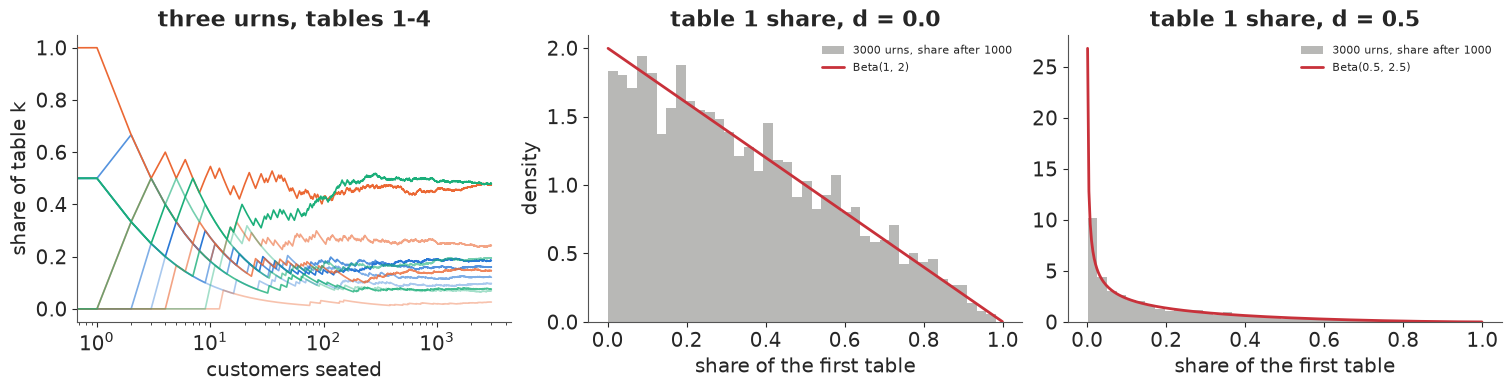

In [3]:
n_run = 3000
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for j, c in enumerate([BLUE, ORANGE, AQUA]):
    sizes_path = np.zeros((n_run, 4))
    # re-run one restaurant, recording the share of its first four tables as customers arrive
    lab, counts = [0], [1]
    for i in range(1, n_run):
        w = np.r_[np.array(counts, float), 2.0]            # alpha = 2, d = 0
        k = rng.choice(len(w), p=w / w.sum())
        if k == len(counts):
            counts.append(1)
        else:
            counts[k] += 1
        sizes_path[i, :min(4, len(counts))] = np.array(counts[:4]) / (i + 1)
    for k in range(4):
        axes[0].plot(np.arange(n_run), sizes_path[:, k], color=c, lw=1.2, alpha=1 - 0.2 * k)
axes[0].set(xscale="log", xlabel="customers seated", ylabel="share of table k",
            title="three urns, tables 1-4")

for ax, d_ in zip(axes[1:], [0.0, 0.5]):
    S = seat(np.full(3000, 2.0), d_, 1000, rng)
    first_share = S[:, 0] / 1000
    ax.hist(first_share, bins=40, density=True, color=GREY, alpha=0.6, label="3000 urns, share after 1000")
    x = np.linspace(0.001, 0.999, 300)
    ax.plot(x, stats.beta(1 - d_, 2.0 + d_).pdf(x), color=RED, lw=2, label=f"Beta({1 - d_:g}, {2 + d_:g})")
    ax.set(xlabel="share of the first table", title=f"table 1 share, d = {d_}")
    ax.legend(fontsize=8)
axes[1].set_ylabel("density");

Each urn's table shares wander early and then freeze (left, log time axis): the first few
customers decide which tables become large, and after that the rich-get-richer rule only
confirms it. Across 3000 urns the share of the first table is spread over the whole interval,
exactly as $\text{Beta}(1 - d, \alpha + d)$ predicts (middle, right): the limit is random, and the
discount makes large first tables *less* likely because it keeps feeding new tables.

### Exchangeability: order does not matter

Multiply the predictive probabilities along a sequence and you get the probability of that
sequence. For five items with labels $(A, A, B, A, C)$ under $\alpha = 1, d = 0.4$ the product
is $1 \cdot \frac{1-d}{\alpha+1} \cdot \frac{\alpha+d}{\alpha+2} \cdots$. Reorder the items
and the individual factors change, but the product does not. Check it on every ordering:

In [4]:
def seq_prob(labels, alpha, d):
    """Probability of a label sequence under the Pitman-Yor predictive rule (labels in any coding)."""
    counts, p = {}, 1.0
    for i, z in enumerate(labels):
        K = len(counts)
        p *= (counts[z] - d) / (alpha + i) if z in counts else (alpha + d * K) / (alpha + i) if i else 1.0
        counts[z] = counts.get(z, 0) + 1
    return p


orders = sorted(set(itertools.permutations("AABAC")))
probs = np.array([seq_prob(o, 1.0, 0.4) for o in orders])
print(f"{len(orders)} distinct orderings of A,A,B,A,C: probability min {probs.min():.6f}, "
      f"max {probs.max():.6f}")
print("first three:", [("".join(o), round(p, 6)) for o, p in zip(orders[:3], probs[:3])])

20 distinct orderings of A,A,B,A,C: probability min 0.020160, max 0.020160
first three: [('AAABC', np.float64(0.02016)), ('AAACB', np.float64(0.02016)), ('AABAC', np.float64(0.02016))]


All twenty orderings have the same probability. So the probability of a *partition* of $n$
items (which items go together, not which label they carry, nor the order they arrived in)
depends only on the block sizes. That function is the **exchangeable partition probability
function** (EPPF). For Pitman-Yor (Pitman 1995):

$$p(n_1, \dots, n_K) = \frac{\prod_{k=1}^{K-1} (\alpha + k d)}{(\alpha + 1)_{n-1}}
\prod_{k=1}^{K} (1 - d)_{n_k - 1},$$

with the rising factorial $(x)_m = x(x+1)\cdots(x+m-1) = \Gamma(x+m)/\Gamma(x)$. Setting
$d = 0$ gives the Ewens sampling formula of population genetics. The data enter only through
$n$, $K$ and the **frequency-of-frequencies** $M_r$ = number of types seen exactly $r$ times,
because $\prod_k (1-d)_{n_k-1} = \prod_r \big[\Gamma(r-d)/\Gamma(1-d)\big]^{M_r}$.

## 2 · The EPPF, checked against brute force

A formula for a probability is worth nothing until checked. Take $n = 5$ items: there are 52
ways to partition them (the Bell number). Simulate the urn 200,000 times, record which items
ended up together, and compare the frequency of each of the 52 partitions with the EPPF.

52 distinct partitions seen (Bell(5) = 52); EPPF sums to 1.000000


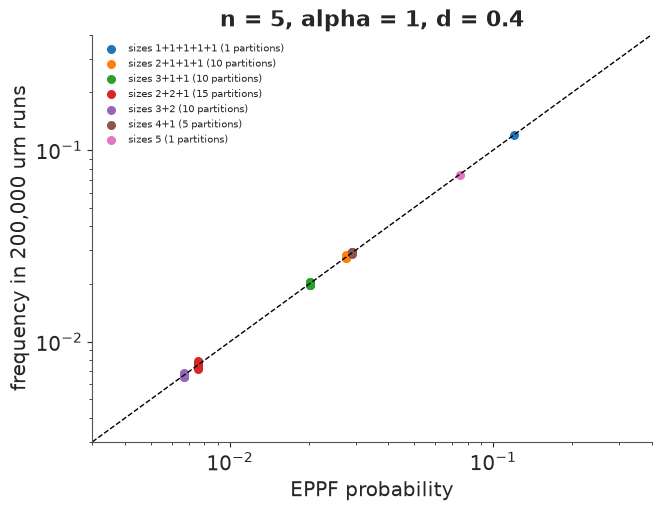

In [5]:
def log_eppf(alpha, d, sizes):
    """log EPPF of the block sizes under Pitman-Yor(alpha, d). NumPy, used for checks."""
    sizes = np.asarray(sizes)
    sizes = sizes[sizes > 0]
    n, K = sizes.sum(), len(sizes)
    return (np.log(alpha + d * np.arange(1, K)).sum() - np.log(alpha + np.arange(1, n)).sum()
            + (gammaln(sizes - d) - gammaln(1 - d)).sum())


def urn_labels(alpha, d, n, R, rng):
    """R urn runs of n items, returning the table of each item (tables numbered by first arrival)."""
    lab = np.zeros((R, n), dtype=int)
    for i in range(1, n):
        counts = np.stack([(lab[:, :i] == k).sum(1) for k in range(i + 1)], axis=1).astype(float)
        K = (counts > 0).sum(1)
        w = np.where(counts > 0, counts - d, 0.0)
        w[np.arange(R), K] = alpha + d * K               # the next free table number is K
        u = rng.random(R) * w.sum(1)
        lab[:, i] = (np.cumsum(w, axis=1) < u[:, None]).sum(1)
    return lab


alpha0, d0, n0 = 1.0, 0.4, 5
lab = urn_labels(alpha0, d0, n0, 200_000, rng)
keys, freq = np.unique(lab, axis=0, return_counts=True)       # a canonical label vector = a set partition
eppf = np.array([np.exp(log_eppf(alpha0, d0, np.bincount(k))) for k in keys])
shape = ["+".join(map(str, sorted(np.bincount(k), reverse=True))) for k in keys]
print(f"{len(keys)} distinct partitions seen (Bell(5) = 52); EPPF sums to {eppf.sum():.6f}")

fig, ax = plt.subplots(figsize=(6.5, 5))
for s, c in zip(sorted(set(shape), key=lambda s: -len(s)), plt.cm.tab10.colors):
    m = np.array(shape) == s
    ax.scatter(eppf[m], freq[m] / len(lab), color=c, s=30, label=f"sizes {s} ({m.sum()} partitions)")
lim = [0.003, 0.4]
ax.plot(lim, lim, color="k", lw=1, ls="--")
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel="EPPF probability",
       ylabel="frequency in 200,000 urn runs", title="n = 5, alpha = 1, d = 0.4")
ax.legend(fontsize=7);

In [6]:
z = (freq / len(lab) - eppf) / np.sqrt(eppf * (1 - eppf) / len(lab))
print(f"standardised differences: max |z| = {np.abs(z).max():.2f} over {len(z)} partitions "
      f"(chi-square p = {stats.chi2(len(z) - 1).sf((z ** 2).sum()):.2f})")

standardised differences: max |z| = 1.99 over 52 partitions (chi-square p = 0.91)


Every point sits on the diagonal, and partitions with the same block sizes (same colour) have
the same probability whatever items they group - exchangeability again. The largest
standardised deviation is what 52 draws of noise produce. The formula is right, and it is
all we need: **the likelihood of the observed partition, with no latent variables at all**.

## 3 · The data: every word of *Moby-Dick*

The book comes from Project Gutenberg as plain text. Tokenisation, stated precisely because it
changes the answer (section 5.3): keep the text from the second "CHAPTER 1. Loomings." (the
first is in the table of contents; this drops the Etymology and Extracts front matter) to the
Gutenberg end marker; lower-case it; a token is a run of letters, optionally joined by
apostrophes (*whale's*, *don't*, *ship's* are single tokens); hyphenated compounds are split
(*sperm-whale* is two tokens); digits and punctuation are dropped.

In [7]:
data.describe("moby_dick")
raw = data.path("moby_dick").read_text(encoding="utf-8")
start = raw.index("CHAPTER 1. Loomings.", raw.index("CHAPTER 1. Loomings.") + 10)
book = raw[start:raw.index("*** END OF THE PROJECT GUTENBERG")]


def tokenise(text, pattern=r"[a-z]+(?:['’][a-z]+)*", lower=True):
    return re.findall(pattern, text.lower() if lower else text)


tokens = np.array(tokenise(book))
vocab, ids = np.unique(tokens, return_inverse=True)     # ids[i] = word type of token i
N_TOK = len(tokens)


def freq_of_freq(ids_):
    """Block sizes -> (r, M_r, n, K)."""
    c = np.bincount(ids_)
    r, M = np.unique(c[c > 0], return_counts=True)
    return r, M, int((r * M).sum()), int(M.sum())


r_all, M_all, n_all, K_all = freq_of_freq(ids)
counts = collections.Counter(tokens)
print(f"{n_all:,} tokens, {K_all:,} types; seen once: {M_all[0]:,} ({M_all[0] / K_all:.0%} of types), "
      f"twice: {M_all[1]:,}, three times: {M_all[2]:,}")
print("most frequent:", counts.most_common(8))
print("a few hapax legomena:", sorted(w for w, c in counts.items() if c == 1)[1000:1008])

moby_dick: Plain UTF-8 text of the novel with the Project Gutenberg header and licence. Not a table: read data.path() and tokenise (see E30).
  source: Herman Melville, Moby-Dick; or, The Whale (1851), Project Gutenberg eBook #2701 (public domain).
  url:    https://www.gutenberg.org/cache/epub/2701/pg2701.txt


212,351 tokens, 17,086 types; seen once: 7,516 (44% of types), twice: 2,862, three times: 1,629
most frequent: [(np.str_('the'), 14174), (np.str_('of'), 6469), (np.str_('and'), 6325), (np.str_('a'), 4629), (np.str_('to'), 4539), (np.str_('in'), 4078), (np.str_('that'), 2950), (np.str_('his'), 2495)]
a few hapax legomena: [np.str_('chafed'), np.str_('chalices'), np.str_('chalking'), np.str_('challenge'), np.str_('chamois'), np.str_('champagne'), np.str_('champed'), np.str_('champions')]


local Heaps exponent, shuffled tokens, n = 1,000-10,000: 0.74
local Heaps exponent, shuffled tokens, n = 10,000-100,000: 0.60
local Heaps exponent, shuffled tokens, n = 100,000-212,351: 0.47


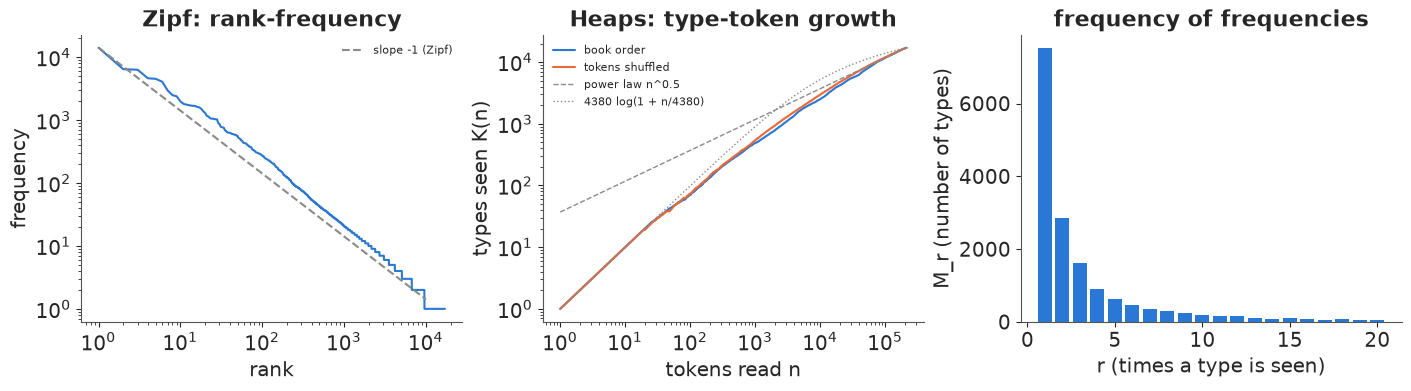

In [8]:
def type_growth(ids_):
    """K after each token: the type-token (Heaps) curve."""
    first = np.zeros(len(ids_), bool)
    first[np.unique(ids_, return_index=True)[1]] = True
    return np.cumsum(first)


perm = rng.permutation(N_TOK)
K_book, K_shuf = type_growth(ids), type_growth(ids[perm])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
f_sorted = np.sort(np.bincount(ids))[::-1]
axes[0].loglog(np.arange(1, K_all + 1), f_sorted, color=BLUE)
axes[0].loglog([1, 1e4], [f_sorted[0], f_sorted[0] / 1e4], color=GREY, ls="--", label="slope -1 (Zipf)")
axes[0].set(xlabel="rank", ylabel="frequency", title="Zipf: rank-frequency")
axes[0].legend(fontsize=8)
nn = np.arange(1, N_TOK + 1)
axes[1].loglog(nn, K_book, color=BLUE, label="book order")
axes[1].loglog(nn, K_shuf, color=ORANGE, label="tokens shuffled")
axes[1].loglog(nn, K_all * (nn / N_TOK) ** 0.5, color=GREY, ls="--", lw=1, label="power law n^0.5")
a_log = 4380.0   # the alpha for which a log(1 + n / alpha) ends at 17,086 types
axes[1].loglog(nn, a_log * np.log1p(nn / a_log), color=GREY, ls=":", lw=1, label="4380 log(1 + n/4380)")
axes[1].set(xlabel="tokens read n", ylabel="types seen K(n)", title="Heaps: type-token growth")
axes[1].legend(fontsize=8)
axes[2].bar(r_all[:20], M_all[:20], color=BLUE)
axes[2].set(xlabel="r (times a type is seen)", ylabel="M_r (number of types)", title="frequency of frequencies")
for a_, b_ in [(1_000, 10_000), (10_000, 100_000), (100_000, N_TOK)]:
    print(f"local Heaps exponent, shuffled tokens, n = {a_:,}-{b_:,}: "
          f"{np.log(K_shuf[b_ - 1] / K_shuf[a_ - 1]) / np.log(b_ / a_):.2f}")

Three views of the same partition. Rank-frequency is close to Zipf's slope of $-1$ over three
decades. The number of types grows roughly like a power of $n$ (Heaps' law), but not a
constant one: the local slope on log-log axes falls from 0.74 between 1,000 and 10,000 tokens
to 0.47 over the second half of the book. The Dirichlet process's
growth, $E[K_n] \approx \alpha \log(1 + n/\alpha)$, can be made to end at the right number of
types, but only with an $\alpha$ in the thousands, and then it has far too many types in the
middle of the book. Almost half the types are **hapax legomena**, words used exactly once. In
book order the curve runs slightly *below* the shuffled one: words cluster in chapters (the
cetology chapters, the try-works), so a stretch of the real text repeats itself more than a
random sample of the same size does. Exchangeable models describe the *shuffled* curve; keep
that difference in mind for section 6.

## 4 · Fitting $(\alpha, d)$ by NUTS on the partition

The model is the EPPF itself: a `pm.Potential` of the log-probability of the observed block
sizes, a function of two parameters. There are no assignments to sample, no truncation and no
label switching - the words are the labels.

**Priors.** $d \sim \text{Uniform}(0, 1)$. For $\alpha$ a log-normal with median $e^4 \approx 55$
and a factor-of-$e^2$ spread either way: large values are possible (a Dirichlet process needs
thousands, as we will see), small values are the norm for power-law data. What these priors
mean is clearest in terms of the number of types they expect after 212,000 tokens.

$$E[K_n] = \frac{\alpha}{d}\left[\frac{(\alpha + d)_n}{(\alpha)_n} - 1\right] \;(d > 0), \qquad
E[K_n] = \sum_{i=0}^{n-1} \frac{\alpha}{\alpha + i} \;(d = 0).$$

In [9]:
def expected_K(alpha, d, n, K0=0, n0=0):
    """E[types after n0 + n tokens] given K0 types in the first n0 (K0 = n0 = 0: the prior mean of K_n)."""
    alpha, d = np.broadcast_arrays(np.asarray(alpha, float), np.asarray(d, float))
    ew = alpha * (digamma(alpha + n0 + n) - digamma(alpha + n0))
    dd = np.where(np.abs(d) < 1e-8, 1e-8, d)
    lr = gammaln(alpha + n0 + dd + n) - gammaln(alpha + n0 + dd) - gammaln(alpha + n0 + n) + gammaln(alpha + n0)
    return K0 + np.where(np.abs(d) < 1e-8, ew, (K0 + alpha / dd) * np.expm1(lr))


a_pr = np.exp(rng.normal(4.0, 2.0, 4000))
d_pr = rng.uniform(0, 1, 4000)
EK_py, EK_ew = expected_K(a_pr, d_pr, n_all), expected_K(a_pr, 0.0, n_all)
for lab_, v in [("Pitman-Yor", EK_py), ("Ewens (d = 0)", EK_ew)]:
    q = np.quantile(v, [0.05, 0.5, 0.95])
    print(f"prior E[K] after {n_all:,} tokens, {lab_:14s}: median {q[1]:>9,.0f}, 90% {q[0]:,.0f} - {q[2]:,.0f}")
print(f"observed K = {K_all:,}")

prior E[K] after 212,351 tokens, Pitman-Yor    : median     9,035, 90% 189 - 157,267
prior E[K] after 212,351 tokens, Ewens (d = 0) : median       473, 90% 22 - 7,473
observed K = 17,086


The Pitman-Yor prior puts the observed 17,086 types comfortably inside its range. Under
$d = 0$ the same prior on $\alpha$ makes 17,086 types a 1-in-20 event or rarer: a Dirichlet process
needs $\alpha$ in the thousands to produce that many, which the prior thinks unlikely but does not
forbid. With 212,000 tokens the likelihood will override it either way.

### A numerical trap first

The obvious way to write the denominator $(\alpha + 1)_{n-1}$ is
`gammaln(alpha + n) - gammaln(alpha + 1)`. Here is the Ewens model written that way, started
at $\log\alpha = 50$. (That start is deliberate, to make the failure reproducible. In an early
draft of this notebook, with a slightly wider prior, two of four chains went out there on their
own during warm-up.)

In [10]:
def eppf_logp(alpha, d, r, M, n, K, stable=True):
    """Pitman-Yor log EPPF as a PyTensor expression, from the frequency-of-frequencies."""
    if stable:
        log_rising = pt.log(alpha + np.arange(1, n)).sum()          # log (alpha + 1)_{n-1}, term by term
    else:
        log_rising = pt.gammaln(alpha + n) - pt.gammaln(alpha + 1)
    return (pt.log(alpha + d * np.arange(1, K)).sum() - log_rising
            + (M * (pt.gammaln(r - d) - pt.gammaln(1 - d))).sum())


def partition_model(r, M, n, K, kind="py", stable=True, name=None):
    with pm.Model(name=name or kind) as m:
        log_alpha = pm.Normal("log_alpha", 4.0, 2.0)
        alpha = pm.Deterministic("alpha", pt.exp(log_alpha))
        d = pm.Uniform("d", 0.0, 1.0) if kind == "py" else pt.constant(0.0)
        pm.Potential("eppf", eppf_logp(alpha, d, r, M, n, K, stable))
    return m


trap = partition_model(r_all, M_all, n_all, K_all, "ewens", stable=False, name="ewens_gammaln")
idata_trap = fit(trap, initvals={"ewens_gammaln::log_alpha": 50.0})
print("chain means of log alpha:", idata_trap.posterior["ewens_gammaln::log_alpha"].mean("draw").round(2).to_numpy())
print("chain means of logp:     ", idata_trap.sample_stats["logp"].mean("draw").round(0).to_numpy())

ewens_gammaln: divergences = 0, max r_hat = 3.221, min ess_bulk = 4
chain means of log alpha: [49.5  50.14 50.63 50.8 ]
chain means of logp:      [-259. -266. -272. -274.]


The chains stay near $\log\alpha = 50$, an $\alpha$ of $10^{21}$, with a log-probability of about
$-270$ - while the true posterior mode ($\log\alpha \approx 8.4$) has a log-probability of
$-1.3$ million. So out there the model looks a million nats *better* than the truth. There
are no divergences; only $\hat R$ gives it away, because each chain drifts about in its own
part of the fake region. The cause is floating point: $\log\Gamma(\alpha + n)$ and
$\log\Gamma(\alpha + 1)$ are both about $10^{23}$ there, the difference we need is about $10^{7}$,
and double precision keeps only 16 significant digits. What remains is $(K - 1)\log\alpha$ plus
rounding noise, which increases without bound. Summing $\log(\alpha + i)$ over
$i = 1, \dots, n-1$ (212,000 terms, a fraction of a millisecond) is accurate everywhere:

In [11]:
a_test = np.array([1e3, 1e10, 1e16, 1e20])
print(pd.DataFrame({"alpha": a_test,
                    "gammaln difference": gammaln(a_test + n_all) - gammaln(a_test + 1),
                    "sum of logs": [np.log(a + np.arange(1, n_all)).sum() for a in a_test]}).to_string(index=False))
del idata_trap

       alpha  gammaln difference  sum of logs
1.000000e+03        2.398696e+06 2.398696e+06
1.000000e+10        4.889542e+06 4.889542e+06
1.000000e+16        7.823296e+06 7.823263e+06
1.000000e+20        9.437184e+06 9.779079e+06


At $\alpha = 10^{16}$ the two already disagree by 30 nats; at $10^{20}$ by $3 \times 10^5$. With the
stable form the same bad start is harmless, and the two models are:

In [12]:
idata_ew = fit(partition_model(r_all, M_all, n_all, K_all, "ewens"), initvals={"ewens::log_alpha": 50.0})
idata_py = fit(partition_model(r_all, M_all, n_all, K_all, "py"))
az.summary(idata_py, var_names=["py::alpha", "py::d"], round_to=3)

ewens: divergences = 0, max r_hat = 1.002, min ess_bulk = 1644


py: divergences = 0, max r_hat = 1.004, min ess_bulk = 1801


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
py::alpha,504.224,28.889,458.832,550.634,1801.247,2209.656,1.004,0.681,0.448
py::d,0.467,0.004,0.460,0.474,1837.828,2181.217,1.003,0.000,0.000


Ewens: alpha = 4,376 (sd 39)
Pitman-Yor: alpha = 504 (sd 29), d = 0.467 (sd 0.0042); corr(log alpha, d) = -0.63
log EPPF at the posterior means: Ewens -1,339,252, Pitman-Yor -1,335,384


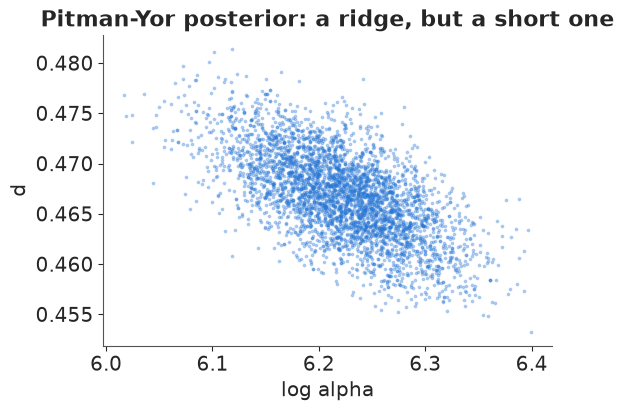

In [13]:
a_ew = draws(idata_ew, "ewens::alpha")
a_py, d_py = draws(idata_py, "py::alpha"), draws(idata_py, "py::d")
print(f"Ewens: alpha = {a_ew.mean():,.0f} (sd {a_ew.std():.0f})")
print(f"Pitman-Yor: alpha = {a_py.mean():.0f} (sd {a_py.std():.0f}), d = {d_py.mean():.3f} (sd {d_py.std():.4f}); "
      f"corr(log alpha, d) = {np.corrcoef(np.log(a_py), d_py)[0, 1]:.2f}")
print(f"log EPPF at the posterior means: Ewens {log_eppf(a_ew.mean(), 0.0, np.bincount(ids)):,.0f}, "
      f"Pitman-Yor {log_eppf(a_py.mean(), d_py.mean(), np.bincount(ids)):,.0f}")

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(np.log(a_py), d_py, s=3, alpha=0.3, color=BLUE)
ax.set(xlabel="log alpha", ylabel="d", title="Pitman-Yor posterior: a ridge, but a short one");

Both samplers are healthy (the line printed by each fit), the Ewens one despite the start at
$\log\alpha = 50$. The data want a discount of about 0.47, known to $\pm 0.004$: a power law.
Forcing $d = 0$ costs about 3,900 nats of log-likelihood - an unthinkable amount for one parameter - and the Ewens model compensates
with an $\alpha$ of several thousand, because the only way a Dirichlet process can produce
17,000 types from 212,000 tokens is to make every draw quite likely to be new.

$\log\alpha$ and $d$ are negatively correlated (-0.63; more discount needs less concentration to make
the same number of types), but with 212,000 tokens the ridge is short and NUTS does not care.

## 5 · Does the data want $d > 0$? Checks that can fail

### 5.1 Posterior predictive: the frequency of frequencies

Simulate the urn with 100 posterior draws of $(\alpha, d)$, all 212,000 customers each, and
compare the number of types seen once, twice, ... with the book.

Ewens     : replicated M_1 = 4,281, M_2 = 2,110, K = 17,092  (book: 7,516, 2,862, 17,086)
Pitman-Yor: replicated M_1 = 8,432, M_2 = 2,242, K = 17,019  (book: 7,516, 2,862, 17,086)


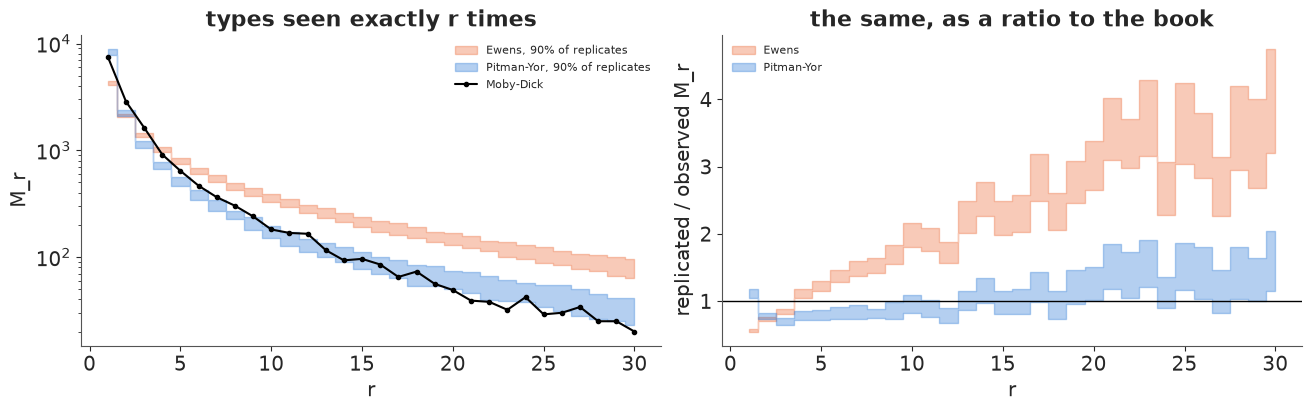

In [14]:
def ppc_M(alpha, d, n, rmax, rng):
    S = seat(alpha, d, n, rng)
    return np.stack([(S == r).sum(1) for r in range(1, rmax + 1)], axis=1), (S > 0).sum(1)


pick = rng.choice(len(a_py), 100, replace=False)
RMAX = 30
M_obs = np.bincount(np.bincount(ids), minlength=RMAX + 1)[1:RMAX + 1]
M_rep = {"Ewens": ppc_M(a_ew[pick], 0.0, n_all, RMAX, rng),
         "Pitman-Yor": ppc_M(a_py[pick], d_py[pick], n_all, RMAX, rng)}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rr = np.arange(1, RMAX + 1)
for (lab_, (Mr, Kr)), c in zip(M_rep.items(), [ORANGE, BLUE]):
    lo, hi = np.quantile(Mr, [0.05, 0.95], axis=0)
    axes[0].fill_between(rr, lo, hi, color=c, alpha=0.35, step="mid", label=f"{lab_}, 90% of replicates")
    axes[1].fill_between(rr, lo / M_obs, hi / M_obs, color=c, alpha=0.35, step="mid", label=lab_)
    print(f"{lab_:10s}: replicated M_1 = {Mr[:, 0].mean():,.0f}, M_2 = {Mr[:, 1].mean():,.0f}, "
          f"K = {Kr.mean():,.0f}  (book: {M_obs[0]:,}, {M_obs[1]:,}, {K_all:,})")
axes[0].plot(rr, M_obs, "k.-", label="Moby-Dick")
axes[0].set(yscale="log", xlabel="r", ylabel="M_r", title="types seen exactly r times")
axes[0].legend(fontsize=8)
axes[1].axhline(1, color="k", lw=1)
axes[1].set(xlabel="r", ylabel="replicated / observed M_r", title="the same, as a ratio to the book")
axes[1].legend(fontsize=8);

The Ewens model gets the total number of types right - it was fitted to do that - but not
how they are distributed: it produces far too few hapaxes (about 4,300 against 7,516) and too
few words seen twice or three times, and from $r = 5$ on too many, two to four times the book's
count by $r = 20$-$30$. A Dirichlet process with a huge $\alpha$ makes many types of similar,
moderate size; the book has a power law with a mass of hapaxes. Pitman-Yor gets the shape
roughly right (within about 20% for $r \le 15$), but the bands miss the book in a systematic
pattern: **too many hapaxes** (about 8,400 against 7,516), too few types seen 2-8 times,
too many seen 15 times or more. That is a real misfit, and the first part of it matters most:
by Good-Turing, the chance that the next token is a new word is about $M_1 / n$. We will meet
it again in the predictions.

### 5.2 Posterior predictive: the type-token curve

Under both models the number of types $K_n$ is a Markov chain on its own: token $i+1$ is new
with probability $(\alpha + d K_i)/(\alpha + i)$ whatever the sizes of the existing types. So
simulating the growth curve needs one random number per token and draw, not a full restaurant.

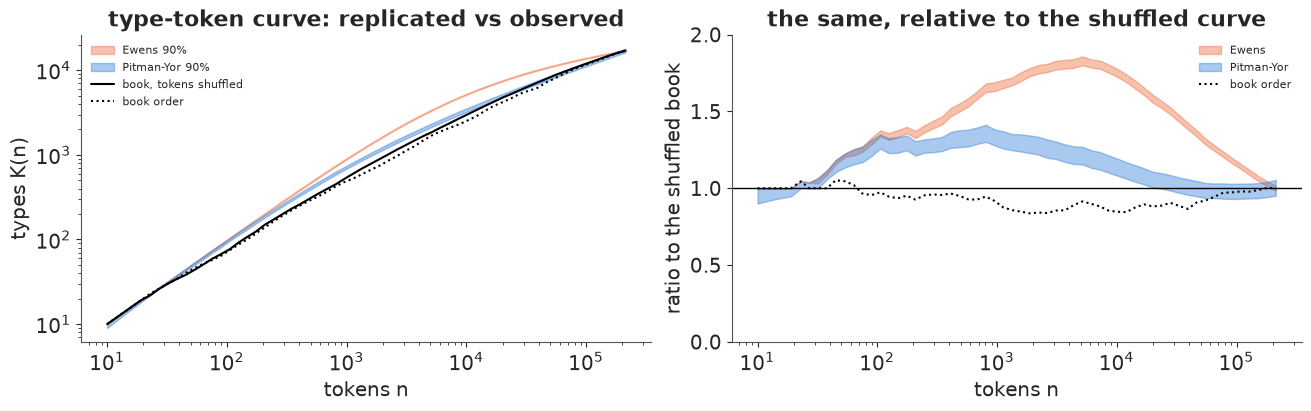

In [15]:
def grow(alpha, d, n0, K0, m, rng, record=()):
    """Types after m more tokens, from n0 tokens / K0 types; vectorised over draws. Returns final K and a dict of K at `record`."""
    alpha, d, K = (np.array(x, float) for x in np.broadcast_arrays(alpha, d, K0))
    rec, record = {}, set(record)
    for j in range(m):
        K += rng.random(K.shape) * (alpha + n0 + j) < alpha + d * K
        if j + 1 in record:
            rec[j + 1] = K.copy()
    return K, rec


checkpoints = np.unique(np.logspace(1, np.log10(n_all), 60).astype(int))
pick = rng.choice(len(a_py), 400, replace=False)
_, g_ew = grow(a_ew[pick], 0.0, 0, 0, n_all, rng, checkpoints)
_, g_py = grow(a_py[pick], d_py[pick], 0, 0, n_all, rng, checkpoints)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for g, c, lab_ in [(g_ew, ORANGE, "Ewens"), (g_py, BLUE, "Pitman-Yor")]:
    G = np.stack([g[k] for k in checkpoints], axis=1)
    lo, hi = np.quantile(G, [0.05, 0.95], axis=0)
    axes[0].fill_between(checkpoints, lo, hi, color=c, alpha=0.4, label=f"{lab_} 90%")
    axes[1].fill_between(checkpoints, lo / K_shuf[checkpoints - 1], hi / K_shuf[checkpoints - 1], color=c, alpha=0.4, label=lab_)
axes[0].loglog(checkpoints, K_shuf[checkpoints - 1], color="k", label="book, tokens shuffled")
axes[0].loglog(checkpoints, K_book[checkpoints - 1], color="k", ls=":", label="book order")
axes[0].set(xlabel="tokens n", ylabel="types K(n)", title="type-token curve: replicated vs observed")
axes[0].legend(fontsize=8)
axes[1].plot(checkpoints, K_book[checkpoints - 1] / K_shuf[checkpoints - 1], color="k", ls=":", label="book order")
axes[1].axhline(1, color="k", lw=1)
axes[1].set(xscale="log", xlabel="tokens n", ylabel="ratio to the shuffled book", ylim=(0, 2),
            title="the same, relative to the shuffled curve")
axes[1].legend(fontsize=8);

Fitted to the whole book, Pitman-Yor's growth curve ends in the right place, but it gets there
along the wrong path: from about 100 tokens on it has too many types (up to 1.4 times the
shuffled book near $n = 1000$), because it believes the vocabulary grows as a *constant* power
of $n$, while the book's local growth exponent falls as the book goes on. The Dirichlet
process is much worse: with $\alpha \approx 4400$ nearly every one of the first few thousand
tokens is "new", so it has up to 1.8 times too many types near $n = 5000$, and it meets the
book only at the very end, where it was fitted.
Book order (dotted) runs *below* the shuffled curve in the middle of the book: in the actual
text, words cluster in chapters, so fewer distinct ones appear in any stretch than in a
random sample of the same size.

### 5.3 Held-out comparison

The partition of the whole book, divided by the partition of its first half, is the
probability of the second half given the first (the EPPF is consistent: adding items to a
partition multiplies its probability by the predictive rule). So the held-out log predictive
density of the second half needs no new code: fit on the first half, then average
$\exp[\log p(\text{whole}) - \log p(\text{first half})]$ over the posterior draws. Book order
and a random half are both reported.

In [16]:
def heldout_lpd(alpha, d, ids_train, ids_all):
    s_all, s_tr = np.bincount(ids_all), np.bincount(ids_train)
    diff = np.array([log_eppf(a, dd, s_all) - log_eppf(a, dd, s_tr) for a, dd in zip(alpha, d)])
    return np.logaddexp.reduce(diff) - np.log(len(diff)), diff.std()


rows, half = [], N_TOK // 2
for order, I in [("book order", ids), ("random half", ids[perm])]:
    r_h, M_h, n_h, K_h = freq_of_freq(I[:half])
    for kind in ["ewens", "py"]:
        idh = fit(partition_model(r_h, M_h, n_h, K_h, kind, name=f"{kind}_half"))
        a_h = draws(idh, f"{kind}_half::alpha")[::4]
        d_h = draws(idh, f"{kind}_half::d")[::4] if kind == "py" else np.zeros_like(a_h)
        lpd, sd = heldout_lpd(a_h, d_h, I[:half], I)
        rows.append({"split": order, "model": kind, "alpha": a_h.mean(), "d": d_h.mean(),
                     "held-out lpd": lpd, "per token": lpd / (N_TOK - half), "sd over draws": sd})
        del idh
heldout = pd.DataFrame(rows)
heldout.round(3)

ewens_half: divergences = 0, max r_hat = 1.001, min ess_bulk = 1911


py_half: divergences = 0, max r_hat = 1.002, min ess_bulk = 1896


ewens_half: divergences = 0, max r_hat = 1.001, min ess_bulk = 1782


py_half: divergences = 0, max r_hat = 1.001, min ess_bulk = 1773


,split,model,alpha,d,held-out lpd,per token,sd over draws
0,book order,ewens,3510.492,0.000,-702763.433,-6.619,28.855
1,book order,py,320.336,0.522,-701754.779,-6.609,17.641
2,random half,ewens,3602.556,0.000,-702406.621,-6.615,25.032
3,random half,py,337.304,0.521,-701461.871,-6.607,17.629


Pitman-Yor predicts the second half better than Ewens by about 1,000 nats in either split
(about 0.01 nats per token, over 106,000 tokens). No approximation stands between the numbers
and the question: this is the exact predictive probability of the held-out partition,
averaged over the first-half posterior. (The log-ratio varies by 20-30 nats between posterior
draws, so the average is carried by a few draws and its Monte Carlo error is several nats;
irrelevant next to a difference of 1,000.) (It is not the probability of the text:
a word's identity - *which* new word, which old word - is not modelled, only which earlier
tokens it matches.) The first-half fit has a larger $d$ (about 0.52) than the whole book: the
local power law of the vocabulary flattens as the book goes on, the misfit of 5.2 again.

### Tokenisation changes $d$

$d$ is a property of the partition, and the partition is made by the tokeniser. A few
reasonable alternatives, fitted by the same model:

In [17]:
def quick_fit(ids_, name):
    r_, M_, n_, K_ = freq_of_freq(ids_)
    idq = fit(partition_model(r_, M_, n_, K_, "py", name=name))
    out = {"tokeniser": name, "tokens": n_, "types": K_, "hapaxes": M_[0],
           "alpha": draws(idq, f"{name}::alpha").mean(), "d": draws(idq, f"{name}::d").mean(),
           "d sd": draws(idq, f"{name}::d").std()}
    del idq
    return out


tok_variants = {
    "lower, apostrophes kept": tokens,
    "case kept": np.array(tokenise(book, r"[A-Za-z]+(?:['’][A-Za-z]+)*", lower=False)),
    "lower, split at apostrophes": np.array(tokenise(book, r"[a-z]+")),
    "lower, first 5 letters": np.array([t[:5] for t in tokens]),
}
tok_table = pd.DataFrame([quick_fit(np.unique(v, return_inverse=True)[1], k.replace(",", "").replace(" ", "_"))
                          for k, v in tok_variants.items()])
tok_table["tokeniser"] = list(tok_variants)
tok_table.round(3)

lower_apostrophes_kept: divergences = 0, max r_hat = 1.004, min ess_bulk = 1801


case_kept: divergences = 0, max r_hat = 1.003, min ess_bulk = 1936


lower_split_at_apostrophes: divergences = 0, max r_hat = 1.001, min ess_bulk = 1636


lower_first_5_letters: divergences = 0, max r_hat = 1.001, min ess_bulk = 1248


,tokeniser,tokens,types,hapaxes,alpha,d,d sd
0,"lower, apostrophes kept",212351,17086,7516,504.224,0.467,0.004
1,case kept,212351,18680,8524,538.109,0.480,0.004
2,"lower, split at apostrophes",214702,16692,7246,493.012,0.463,0.004
3,"lower, first 5 letters",212351,9441,2722,617.816,0.289,0.006


Keeping capitals makes *Whale* and *whale* different types and adds about 1,600 types, 1,000
of them hapaxes, and raises $d$ by three posterior standard deviations; splitting at apostrophes
(*whale's* becomes *whale* + *s*) changes little; truncating every word to five letters, a crude
stemmer, merges inflections and drops $d$ from 0.47 to 0.29. Posterior uncertainty about $d$ is
tiny, uncertainty about the tokeniser is not. Report $d$ together with how the text was cut,
and compare corpora only under the same tokeniser.

## 6 · The unseen-species problem

After $n$ tokens with $K$ types, how many **new** types will the next $m$ tokens contain? Under
Pitman-Yor the answer, given $(\alpha, d)$, has a closed form (Favaro, Lijoi, Mena & Prünster
2009):

$$E[K^{\text{new}}_m \mid n, K] = \Big(K + \frac{\alpha}{d}\Big)
\left[\frac{(\alpha + n + d)_m}{(\alpha + n)_m} - 1\right],$$

(`expected_K` above, with `K0, n0`); the full predictive distribution comes from running the
growth chain forward from $(n, K)$ - `grow`. Both depend on the data only through $n$ and $K$:
given the parameters, the frequency-of-frequencies is irrelevant; it matters only through the
posterior of $(\alpha, d)$.

The classical, model-free answer is **Good-Toulmin**: with $t = m / n$,

$$U_{GT}(t) = -\sum_{r \ge 1} (-t)^r M_r .$$

It is nearly unbiased for $t \le 1$ and useless beyond: the alternating terms grow like $t^r$.
Efron & Thisted (1976) and Orlitsky, Suresh & Wu (2016) tame it by shrinking the high-$r$ terms
with a binomial tail probability (the **smoothed Good-Toulmin**, SGT, used below with the
weights of Orlitsky et al.).

In [18]:
def good_toulmin(r, M, n, m):
    t = m / n
    with np.errstate(over="ignore", invalid="ignore"):
        return float(-np.sum((-t) ** r.astype(float) * M))


def smoothed_gt(r, M, n, m):
    """Smoothed Good-Toulmin with Binomial(k, 2/(t+2)) tail weights (Orlitsky, Suresh & Wu 2016)."""
    t = m / n
    if t <= 1:
        return good_toulmin(r, M, n, m)
    k = max(int(round(0.5 * np.log(n * t ** 2 / (t - 1)) / np.log(3))), 1)
    keep = r <= k
    return float(-np.sum((-t) ** r[keep] * stats.binom(k, 2 / (t + 2)).sf(r[keep] - 1) * M[keep]))


r_h, M_h, n_h, K_h = freq_of_freq(ids[:half])
print("Good-Toulmin from the first half of the book, predicting m more tokens:")
for t in [0.5, 1.0, 1.05, 1.2, 1.5, 2.0]:
    m = int(t * n_h)
    print(f"  t = {t:4.2f}: GT = {good_toulmin(r_h, M_h, n_h, m):>12.4g}   SGT = {smoothed_gt(r_h, M_h, n_h, m):>8.0f}")
print(f"  truth at t = 1 (the second half): {K_all - K_h:,} new types")

Good-Toulmin from the first half of the book, predicting m more tokens:
  t = 0.50: GT =         2606   SGT =     2606
  t = 1.00: GT =         4670   SGT =     4670
  t = 1.05: GT =   4.713e+141   SGT =     4814
  t = 1.20: GT =          inf   SGT =     5329
  t = 1.50: GT =          nan   SGT =     6286
  t = 2.00: GT =          nan   SGT =     7687
  truth at t = 1 (the second half): 4,998 new types


At $t = 1$ (predict the second half from the first) Good-Toulmin says 4,670 against a true
4,998 - within 7%, in book order, with no model at all. Five per cent further out the sum is
$10^{141}$, and at $t = 1.2$ it overflows: the most frequent word is seen about 7,000 times in the
first half, and the term $t^{7000} M_{7000}$ decides everything. SGT stays finite.

### 6.1 Predicting the rest of the book from its beginning

Now the honest test. Take the first 1%, 2%, 5%, 10%, 25% or 50% of the book, fit Ewens and
Pitman-Yor to it, and predict how many new types the *rest* of the book contains: $t$ from 99
down to 1. For each split we need a posterior; with two parameters a grid is exact and much
faster than compiling a model per split, so the fits in this section use a grid over
$(\log\alpha, d)$ with the same priors (the check below compares it with NUTS).

In [19]:
def loglik_grid(la, dgrid, r, M, n, K):
    """log EPPF on a (d, log alpha) grid."""
    a = np.exp(la)
    rising = np.array([np.log(ai + np.arange(1, n)).sum() for ai in a])
    k = np.arange(1, K)
    out = np.array([np.log(a[:, None] + dj * k[None, :]).sum(1) - rising
                    + (M * (gammaln(r - dj) - gammaln(1 - dj))).sum() for dj in dgrid])
    return out


def grid_posterior(ids_, rng, size=1000, ewens=False, G=50):
    """Posterior draws of (alpha, d) on an adaptive grid: coarse pass, then zoom to +-6 sd."""
    r, M, n, K = freq_of_freq(ids_)
    la, dg = np.linspace(-2, 10, G), (np.array([0.0]) if ewens else np.linspace(0, 0.99, G))
    for _ in range(3):
        L = loglik_grid(la, dg, r, M, n, K) + stats.norm(4, 2).logpdf(la)[None, :]
        w = np.exp(L - L.max())
        w /= w.sum()
        pa, pd_ = w.sum(0), w.sum(1)
        ma, md = pa @ la, pd_ @ dg
        sa, sd = max(np.sqrt(pa @ (la - ma) ** 2), (la[1] - la[0]) / 2), max(np.sqrt(pd_ @ (dg - md) ** 2), 1e-4)
        la = np.linspace(ma - 6 * sa, ma + 6 * sa, G)
        if not ewens:
            dg = np.linspace(max(md - 6 * sd, 0.0), min(md + 6 * sd, 0.999), G)
    L = loglik_grid(la, dg, r, M, n, K) + stats.norm(4, 2).logpdf(la)[None, :]
    w = np.exp(L - L.max()).ravel()
    jd, ja = np.unravel_index(rng.choice(w.size, size=size, p=w / w.sum()), L.shape)
    hd = dg[1] - dg[0] if not ewens else 0.0
    a = np.exp(la[ja] + rng.uniform(-0.5, 0.5, size) * (la[1] - la[0]))
    return a, np.clip(dg[jd] + rng.uniform(-0.5, 0.5, size) * hd, 0, 0.999)


a_g, d_g = grid_posterior(ids[perm][:half], rng, 2000)
chk = heldout.set_index(["split", "model"])
print(f"grid, random half: alpha {a_g.mean():.1f} (sd {a_g.std():.1f}), d {d_g.mean():.4f} (sd {d_g.std():.4f})")
print(f"NUTS, random half: alpha {chk.loc[('random half', 'py'), 'alpha']:.1f}, d {chk.loc[('random half', 'py'), 'd']:.4f}")

grid, random half: alpha 335.4 (sd 25.8), d 0.5207 (sd 0.0051)
NUTS, random half: alpha 337.3, d 0.5208


In [20]:
fractions = [0.01, 0.02, 0.05, 0.1, 0.25, 0.5]
rows = []
for order, I in [("book order", ids), ("shuffled", ids[perm])]:
    total_types = K_all
    for f in fractions:
        n_tr = int(f * N_TOK)
        m = N_TOK - n_tr
        r_, M_, _, K_tr = freq_of_freq(I[:n_tr])
        truth = total_types - K_tr
        out = {"order": order, "fraction": f, "t": m / n_tr, "truth": truth,
               "GT": good_toulmin(r_, M_, n_tr, m), "SGT": smoothed_gt(r_, M_, n_tr, m)}
        for kind in ["ewens", "py"]:
            a_, d_ = grid_posterior(I[:n_tr], rng, 500, ewens=(kind == "ewens"))
            new, _ = grow(a_, d_, n_tr, K_tr, m, rng)
            new -= K_tr
            out[f"{kind}_lo"], out[f"{kind}_med"], out[f"{kind}_hi"] = np.quantile(new, [0.05, 0.5, 0.95])
            if kind == "py":
                out["d"] = d_.mean()
                out["py_closed_form"] = (expected_K(a_, d_, m, K_tr, n_tr) - K_tr).mean()
        rows.append(out)
pred = pd.DataFrame(rows)
pred[["order", "fraction", "t", "truth", "ewens_med", "py_lo", "py_med", "py_hi", "py_closed_form", "SGT", "GT", "d"]].round(3)

,order,fraction,t,truth,ewens_med,py_lo,py_med,py_hi,py_closed_form,SGT,GT,d
0,book order,0.01,99.024,16263,2159.0,16396.15,19177.0,22385.70,19280.606,3084.003,-3.205572e+231,0.682
1,book order,0.02,49.000,15634,2914.0,18284.40,20381.5,22615.40,20382.247,7329.533,-inf,0.683
2,book order,0.05,19.001,14466,3221.0,14901.90,15937.5,16949.25,15934.144,6275.879,NaN,0.644
3,book order,0.10,9.000,12739,3707.5,13320.60,13953.0,14559.20,13981.332,10918.489,NaN,0.613
4,book order,0.25,3.000,9227,3447.0,9642.90,9918.5,10258.05,9933.725,8266.392,NaN,0.575
5,book order,0.50,1.000,4998,2376.5,5354.95,5520.5,5693.10,5521.979,4650.071,4.670149e+03,0.522
6,shuffled,0.01,99.024,16109,3017.0,25821.10,29755.0,33675.15,29865.570,6787.927,-2.251987e+303,0.741
7,shuffled,0.02,49.000,15445,3637.5,25676.00,28009.0,30531.05,28056.143,10975.315,-inf,0.734
8,shuffled,0.05,19.001,13985,4241.0,19946.65,21217.5,22290.70,21203.915,7163.811,NaN,0.678
9,shuffled,0.10,9.000,12169,4459.5,16406.00,17101.5,17839.05,17086.686,9051.417,NaN,0.640


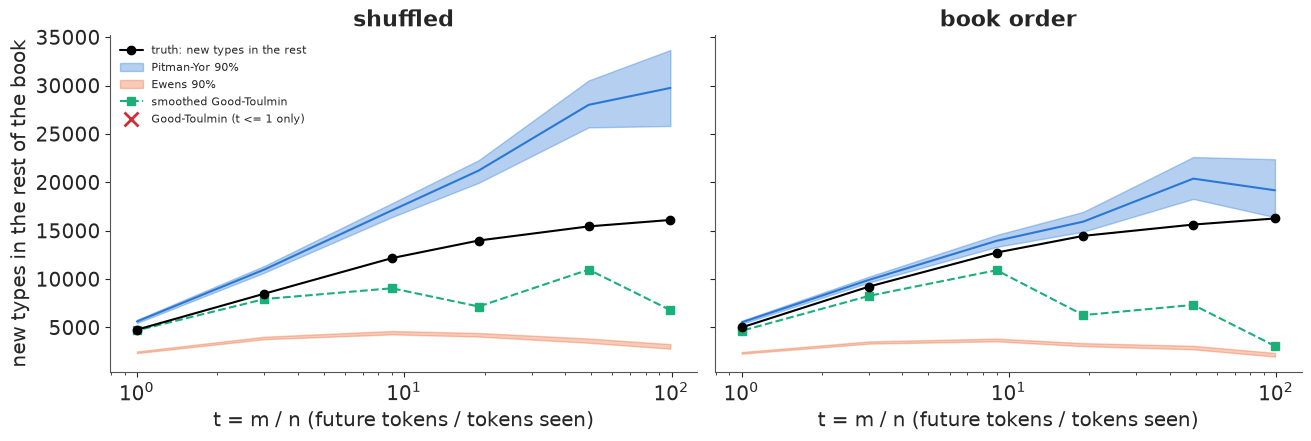

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
for ax, order in zip(axes, ["shuffled", "book order"]):
    p = pred[pred.order == order]
    ax.plot(p.t, p.truth, "ko-", label="truth: new types in the rest", zorder=5)
    ax.fill_between(p.t, p.py_lo, p.py_hi, color=BLUE, alpha=0.35, label="Pitman-Yor 90%")
    ax.plot(p.t, p.py_med, color=BLUE)
    ax.fill_between(p.t, p.ewens_lo, p.ewens_hi, color=ORANGE, alpha=0.35, label="Ewens 90%")
    ax.plot(p.t, p.SGT, "s--", color=AQUA, label="smoothed Good-Toulmin")
    gt_ok = p.t <= 1
    ax.plot(p.t[gt_ok], p.GT[gt_ok], "x", color=RED, ms=10, mew=2, label="Good-Toulmin (t <= 1 only)")
    ax.set(xscale="log", xlabel="t = m / n (future tokens / tokens seen)", title=order)
axes[0].set_ylabel("new types in the rest of the book")
axes[0].legend(fontsize=8);

Read the shuffled panel first - there the model's exchangeability assumption holds by
construction:

* **Ewens** predicts a fraction of the truth at every $t$ (2,400 of 4,800 new types at $t = 1$,
  3,000 of 16,000 at $t = 99$). Logarithmic growth cannot keep up with a power law.
* **Pitman-Yor** has the right *order of magnitude* everywhere, from $t = 1$ to $t = 99$, where
  no classical estimator has anything to say - but it **overpredicts**: by about 18% at $t = 1$,
  30% at $t = 3$ and 85% at $t = 99$, and its 90% intervals miss the truth every time. The
  discount fitted to a small sample is larger (the `d` column rises from 0.52 to 0.74 as the
  training sample shrinks from half the book to 1%): the vocabulary grows fastest at the start
  and then slows down, and a model with one constant power law extrapolates the early rate.
  Posterior uncertainty about $(\alpha, d)$ is small; the model's error is not.
* **Good-Toulmin** is nearly exact at $t = 1$ (4,718 against 4,770) and useless for every $t > 1$.
  **SGT** is finite everywhere and closer than Pitman-Yor up to $t \approx 9$ (it errs low where
  Pitman-Yor errs high), but it is erratic further out - not even monotone in $t$ - and comes
  with no uncertainty.

In book order the truth is a little *larger* at every $t$ (the rest of the book brings new
subjects with their own vocabulary) and the opening chapters give a smaller discount than a
random sample of the same size (except at half the book, where the two agree), so Pitman-Yor's error shrinks to 7-30% - still outside its
intervals at every $t$, and SGT is no more stable. The smaller error in book order is two
departures from the model partly cancelling, not calibration; the next section shows it.

### 6.2 Coverage over many windows

One split is one data point. Take 30 windows: 5,000 tokens to train on, predict the number
of new types in the next 10,000 ($t = 2$). "Book order" uses 15,000 consecutive tokens starting at a
random place; "random" draws 15,000 tokens at random from the whole book, where the
exchangeability assumption is true by construction.

In [22]:
n_tr, m = 5000, 10000
rows = []
for w in range(30):
    s0 = rng.integers(0, N_TOK - n_tr - m)
    for order, J in [("book order", ids[s0:s0 + n_tr + m]), ("random", ids[rng.choice(N_TOK, n_tr + m, replace=False)])]:
        tr, te = J[:n_tr], J[n_tr:]
        r_, M_, _, K_tr = freq_of_freq(tr)
        truth = len(np.setdiff1d(np.unique(te), np.unique(tr)))
        out = {"order": order, "truth": truth, "SGT": smoothed_gt(r_, M_, n_tr, m)}
        for kind in ["ewens", "py"]:
            a_, d_ = grid_posterior(tr, rng, 400, ewens=(kind == "ewens"), G=40)
            new = grow(a_, d_, n_tr, K_tr, m, rng)[0] - K_tr
            out[f"{kind}_lo"], out[f"{kind}_med"], out[f"{kind}_hi"] = np.quantile(new, [0.05, 0.5, 0.95])
        rows.append(out)
cov = pd.DataFrame(rows)
for kind in ["ewens", "py"]:
    cov[f"{kind}_covers"] = (cov.truth >= cov[f"{kind}_lo"]) & (cov.truth <= cov[f"{kind}_hi"])
    cov[f"{kind}_rel_err"] = cov[f"{kind}_med"] / cov.truth - 1
cov["SGT_rel_err"] = cov.SGT / cov.truth - 1
summary = cov.groupby("order").agg(
    truth=("truth", "mean"), py_covers=("py_covers", "mean"), ewens_covers=("ewens_covers", "mean"),
    py_bias=("py_rel_err", "mean"), py_rmse=("py_rel_err", lambda x: np.sqrt(np.mean(x ** 2))),
    sgt_bias=("SGT_rel_err", "mean"), sgt_rmse=("SGT_rel_err", lambda x: np.sqrt(np.mean(x ** 2))),
    py_width=("py_hi", "mean"))
summary["py_width"] = (cov.py_hi - cov.py_lo).groupby(cov.order).mean() / summary.truth
summary.round(3)

,truth,py_covers,ewens_covers,py_bias,py_rmse,sgt_bias,sgt_rmse,py_width
order,,,,,,,,
book order,1946.667,0.167,0.0,-0.120,0.164,-0.188,0.217,0.114
random,2075.200,0.400,0.0,0.076,0.086,0.002,0.043,0.121


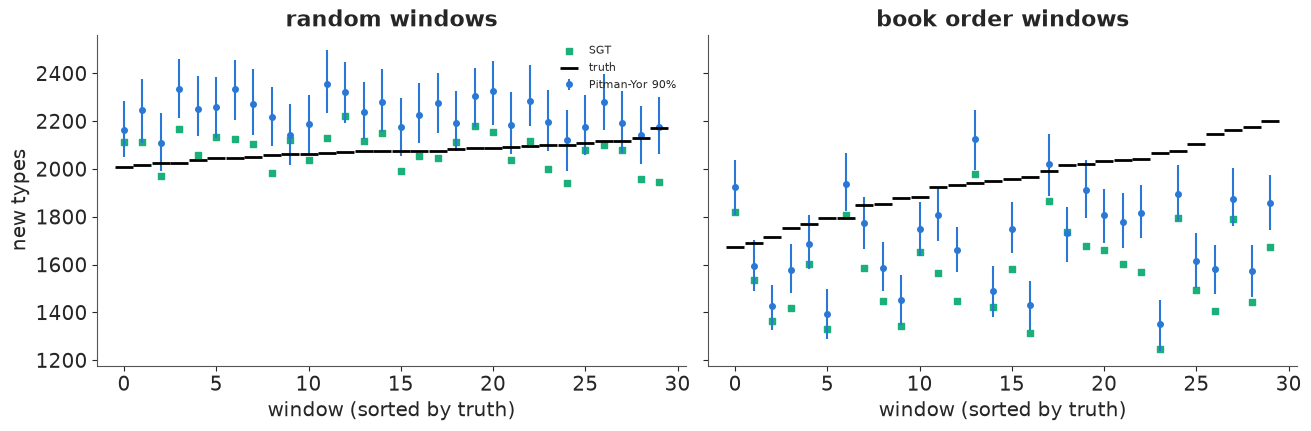

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, order in zip(axes, ["random", "book order"]):
    c = cov[cov.order == order].sort_values("truth").reset_index(drop=True)
    x = np.arange(len(c))
    ax.errorbar(x, c.py_med, yerr=[c.py_med - c.py_lo, c.py_hi - c.py_med], fmt="o", color=BLUE, ms=4, label="Pitman-Yor 90%")
    ax.scatter(x, c.SGT, marker="s", color=AQUA, s=18, label="SGT")
    ax.scatter(x, c.truth, marker="_", color="k", s=150, lw=2, label="truth", zorder=5)
    ax.set(xlabel="window (sorted by truth)", title=f"{order} windows")
axes[0].set_ylabel("new types")
axes[0].legend(fontsize=8);

On random samples Pitman-Yor is biased high by about 8% and its 90% intervals cover the
truth in 12 of 30 windows: the same misfit as before (too many hapaxes, so too high a rate of
new types), with intervals that know only about parameter uncertainty (their width is about
12% of the truth). SGT is essentially unbiased here, with an error of about 4%. In book order
everything gets worse: the truth varies far more between windows than any exchangeable model
allows (some stretches of the book repeat themselves, some change subject), Pitman-Yor is now
biased *low* by about 12% and covers in 5 of 30 windows, and SGT is low by about 19%. Ewens
never covers. None of this shows in the posterior itself, which is as confident in book order
as in random order - only held-out checks reveal it.

## 7 · A forest: when the discount wants to be negative

The Barro Colorado Island plot is a 50-hectare census of every tree with a trunk at least
10 cm across, in fifty 1-ha plots (100 m x 100 m, numbered in columns of five from west to east,
so plots 1-25 are the western half). Individuals are tokens, species are types. Is a forest
a power law like a vocabulary?

In [24]:
def read_rdata(path):
    """Minimal reader for R's XDR serialisation (.rda/.RData): named lists, vectors, strings (see E23/E24/E28)."""
    raw_ = open(path, "rb").read()
    buf = lzma.decompress(raw_) if raw_[:2] == b"\xfd7" else gzip.decompress(raw_)
    assert buf[:7] in (b"RDX2\nX\n", b"RDX3\nX\n"), "not an XDR R data file"
    pos, refs = 7, []

    def i32():
        nonlocal pos
        pos += 4
        return struct.unpack(">i", buf[pos - 4:pos])[0]

    def item():
        nonlocal pos
        flags = i32()
        kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
        if kind == 254:
            return None
        if kind == 255:
            return refs[(flags >> 8) - 1]
        if kind == 1:
            refs.append(item())
            return refs[-1]
        if kind == 9:
            n = i32()
            pos += max(n, 0)
            return None if n == -1 else buf[pos - n:pos].decode()
        if kind == 2:
            out = {}
            while kind == 2:
                _ = item() if has_attr else None
                tag = item() if has_tag else None
                out[tag] = item()
                flags = i32()
                kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
            return out
        n = i32()
        if kind in (10, 13):
            value, pos = np.frombuffer(buf, ">i4", n, pos).astype(int), pos + 4 * n
        elif kind == 14:
            value, pos = np.frombuffer(buf, ">f8", n, pos).astype(float), pos + 8 * n
        elif kind in (16, 19):
            value = [item() for _ in range(n)]
        else:
            raise NotImplementedError(f"R type {kind}")
        attrs = item() if has_attr else None
        if kind == 19 and attrs and "names" in attrs:
            value = dict(zip(attrs["names"], value))
        return value

    version = i32()
    pos += 8
    if version == 3:
        pos += 4 + struct.unpack(">i", buf[pos:pos + 4])[0]
    return item()


data.describe("bci_trees")
bci = pd.DataFrame(read_rdata(data.path("bci_trees"))["BCI"]).astype(int)   # 50 plots x 225 species
sp_tot = bci.sum(axis=0).to_numpy()
r_b, M_b, n_b, K_b = freq_of_freq(np.repeat(np.arange(len(sp_tot)), sp_tot))
print(f"{n_b:,} trees, {K_b} species; singletons {M_b[0]}, doubletons {M_b[1]}; "
      f"commonest: {bci.sum(axis=0).sort_values().index[-1]} ({sp_tot.max():,} trees)")
print(f"hapax share of types: {M_b[0] / K_b:.0%} (Moby-Dick: {M_all[0] / K_all:.0%})")

bci_trees: Counts of 225 tree species (stems >= 10 cm diameter at breast height) in 50 contiguous 1-ha plots (21457 trees). Not a table: an R serialisation (gzip XDR) of a 50 x 225 data frame - parse data.path() (see E30).
  source: Condit et al. (2002, Science 295:666), Barro Colorado Island 50-ha forest plot, Panama; as shipped with the R package `vegan` (Oksanen et al.).
  url:    https://raw.githubusercontent.com/cran/vegan/master/data/BCI.rda
21,457 trees, 225 species; singletons 19, doubletons 13; commonest: Faramea.occidentalis (1,717 trees)
hapax share of types: 8% (Moby-Dick: 44%)


8% of the species are singletons, against 44% of the words. A power law would need far
more rare species. Fit Ewens and Pitman-Yor with the same priors:

In [25]:
idata_bew = fit(partition_model(r_b, M_b, n_b, K_b, "ewens", name="bci_ewens"))
idata_bpy = fit(partition_model(r_b, M_b, n_b, K_b, "py", name="bci_py"), target_accept=0.95)  # d sits at a boundary
print(f"Ewens alpha = {draws(idata_bew, 'bci_ewens::alpha').mean():.1f}; Pitman-Yor d: posterior mean "
      f"{draws(idata_bpy, 'bci_py::d').mean():.3f}, 95th percentile {np.quantile(draws(idata_bpy, 'bci_py::d'), 0.95):.3f}")

bci_ewens: divergences = 0, max r_hat = 1.003, min ess_bulk = 1626


bci_py: divergences = 0, max r_hat = 1.004, min ess_bulk = 1082
Ewens alpha = 34.9; Pitman-Yor d: posterior mean 0.009, 95th percentile 0.028


The discount piles up against its lower bound of zero. The Pitman-Yor family continues below
zero: with $d = -\sigma < 0$ and $\alpha = N\sigma$ for an integer $N$, the urn is the
Dirichlet-multinomial for a **finite pool of $N$ species** with symmetric weights
$\text{Dirichlet}(\sigma, \dots, \sigma)$ (the "new type" probability $\sigma (N - K)/(N\sigma + i)$
reaches zero once all $N$ have been seen). The EPPF formula is unchanged:
$\prod_{k=1}^{K-1}(\alpha + kd) = \sigma^{K-1} (N-1)!/(N-K)!$. $N$ is an unknown integer, so we
marginalise it by summing over $N = K, \dots, K + 3000$ inside the potential with a $1/N$
prior, and put a log-normal prior on $\sigma$. As $\sigma \to 0$ with $N\sigma$ fixed, this
model becomes Ewens, so it nests the $d = 0$ answer.

In [26]:
N_EXTRA = 3000


def finite_model(r, M, n, K, name):
    N_grid = K + np.arange(N_EXTRA + 1)
    log_prior_N = -np.log(N_grid) - np.log(np.sum(1 / N_grid))
    with pm.Model(name=name) as m:
        log_sigma = pm.Normal("log_sigma", 0.0, 2.0)
        sigma = pm.Deterministic("sigma", pt.exp(log_sigma))
        a = N_grid * sigma
        lp_N = (gammaln(N_grid) - gammaln(N_grid - K + 1) + (K - 1) * log_sigma
                - (pt.gammaln(a + n) - pt.gammaln(a + 1))              # alpha <= 3200 sigma: no cancellation here
                + (M * (pt.gammaln(r + sigma) - pt.gammaln(1 + sigma))).sum() + log_prior_N)
        pm.Potential("eppf", pt.logsumexp(lp_N))
        pm.Deterministic("log_post_N", lp_N)                           # for recovering p(N | sigma, data)
    return m


def posterior_N(idata, name, thin=4):
    """One draw of N from p(N | sigma, data) per (thinned) posterior draw of sigma."""
    lp = idata.posterior[f"{name}::log_post_N"].to_numpy().reshape(-1, N_EXTRA + 1)[::thin]
    p = np.exp(lp - lp.max(1, keepdims=True))
    p /= p.sum(1, keepdims=True)
    return np.array([rng.choice(N_EXTRA + 1, p=pi) for pi in p])


idata_bfin = fit(finite_model(r_b, M_b, n_b, K_b, "bci_finite"), target_accept=0.95)
sig = draws(idata_bfin, "bci_finite::sigma")[::4]                  # thinned alongside N below
N_post = K_b + posterior_N(idata_bfin, "bci_finite")
print(f"sigma = {sig.mean():.3f} (90% {np.quantile(sig, 0.05):.3f}-{np.quantile(sig, 0.95):.3f}); "
      f"species pool N: median {np.median(N_post):.0f}, 90% {np.quantile(N_post, 0.05):.0f}-{np.quantile(N_post, 0.95):.0f}; "
      f"P(N within 200 of the grid end) = {np.mean(N_post > K_b + N_EXTRA - 200):.3f}")

bci_finite: divergences = 0, max r_hat = 1.005, min ess_bulk = 1082
sigma = 0.162 (90% 0.084-0.244); species pool N: median 366, 90% 296-552; P(N within 200 of the grid end) = 0.000


The finite pool has a clear posterior: about $\sigma \approx 0.16$ and a few hundred species,
many more than the 225 seen but not unboundedly many. (The grid end is never approached, so the
truncation at $K + 3000$ does not bite.) The numbers are a statement about *this model*: that
the species abundances look like a symmetric Dirichlet with a small parameter. The frequency of
frequencies says whether that is believable:

highest log EPPF among posterior draws: {'Ewens': np.float64(-91230.4), 'Pitman-Yor, d >= 0': np.float64(-91230.4), 'finite pool': np.float64(-91222.7)}


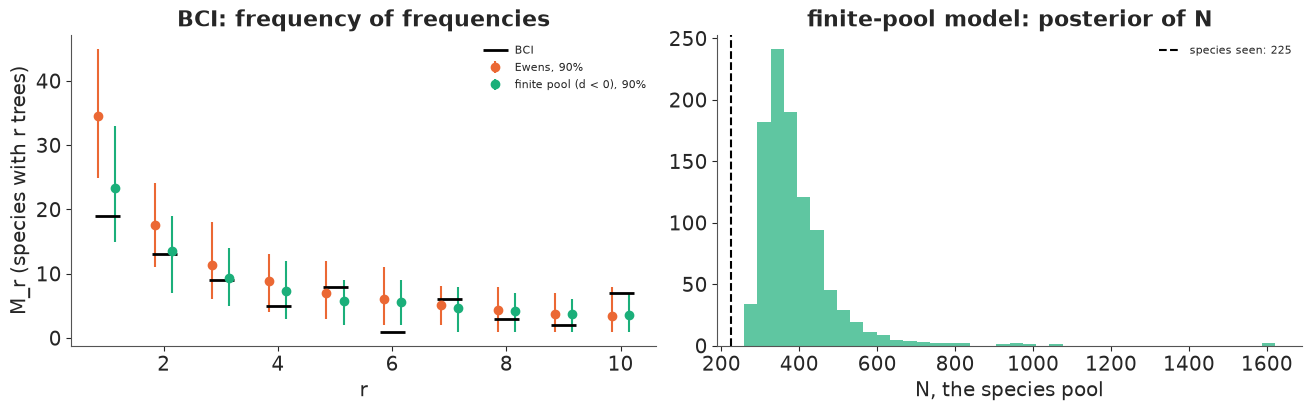

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pick = rng.choice(len(sig), 100, replace=False)
rr = np.arange(1, 11)
M_b_obs = np.bincount(sp_tot, minlength=11)[1:11]
a_bew = draws(idata_bew, "bci_ewens::alpha")
best = {"Ewens": max(log_eppf(a, 0.0, sp_tot) for a in a_bew[::4]),
        "Pitman-Yor, d >= 0": max(log_eppf(a, d, sp_tot) for a, d in zip(draws(idata_bpy, "bci_py::alpha")[::4],
                                                                           draws(idata_bpy, "bci_py::d")[::4])),
        "finite pool": max(log_eppf(N * s_, -s_, sp_tot) for N, s_ in zip(N_post, sig))}
print("highest log EPPF among posterior draws:", {k: round(v, 1) for k, v in best.items()})
reps = {"Ewens": ppc_M(a_bew[pick], 0.0, n_b, 10, rng)[0],
        "finite pool (d < 0)": ppc_M(N_post[pick] * sig[pick], -sig[pick], n_b, 10, rng)[0]}
for (lab_, Mr), c, off in zip(reps.items(), [ORANGE, AQUA], [-0.15, 0.15]):
    lo, hi = np.quantile(Mr, [0.05, 0.95], axis=0)
    axes[0].errorbar(rr + off, Mr.mean(0), yerr=[Mr.mean(0) - lo, hi - Mr.mean(0)], fmt="o", color=c, label=f"{lab_}, 90%")
axes[0].plot(rr, M_b_obs, "k_", ms=18, mew=2, label="BCI")
axes[0].set(xlabel="r", ylabel="M_r (species with r trees)", title="BCI: frequency of frequencies")
axes[0].legend(fontsize=8)
axes[1].hist(N_post, bins=40, color=AQUA, alpha=0.7)
axes[1].axvline(K_b, color="k", ls="--", label=f"species seen: {K_b}")
axes[1].set(xlabel="N, the species pool", title="finite-pool model: posterior of N")
axes[1].legend(fontsize=8);

Ewens (a Dirichlet process) expects about 35 singletons, and the forest has 19 - outside
the replicate band; the finite pool expects about 23 and brackets the observed counts for
$r \le 3$. The best log-likelihoods differ by about 8 nats (printed above): a forest of 21,000
trees has much less to say about rare species than a book has about rare words, and both
models miss some individual $M_r$ (one species with exactly six trees, where both expect about
six). The
evidence for a negative discount is suggestive, not overwhelming - which is why the next test
is out of sample.

### Unseen species, honestly: from the western half to the eastern half

Fit on plots 1-25 (the western 25 ha), predict how many species found in plots 26-50 were not
in the west. Here $t = m/n$ is just above 1, where Good-Toulmin should be at its best.

In [28]:
west, east = bci.iloc[:25].sum(axis=0).to_numpy(), bci.iloc[25:].sum(axis=0).to_numpy()
truth_east = int(((east > 0) & (west == 0)).sum())
ids_w = np.repeat(np.arange(len(west)), west)
r_w, M_w, n_w, K_w = freq_of_freq(ids_w)
m_e = int(east.sum())
print(f"west: {n_w:,} trees, {K_w} species (commonest: {west.max()} trees); east: {m_e:,} trees; species new in the east: {truth_east}; t = {m_e / n_w:.3f}")
print(f"Good-Toulmin: {good_toulmin(r_w, M_w, n_w, m_e):.4g}   smoothed GT: {smoothed_gt(r_w, M_w, n_w, m_e):.1f}   "
      f"GT at t = 1 exactly: {good_toulmin(r_w, M_w, n_w, n_w):.1f}")

idata_wew = fit(partition_model(r_w, M_w, n_w, K_w, "ewens", name="west_ewens"))
idata_wfin = fit(finite_model(r_w, M_w, n_w, K_w, "west_finite"), target_accept=0.95)
a_w = draws(idata_wew, "west_ewens::alpha")
sig_w = draws(idata_wfin, "west_finite::sigma")[::4]
N_w = K_w + posterior_N(idata_wfin, "west_finite")
new_ew = grow(a_w[::4], 0.0, n_w, K_w, m_e, rng)[0] - K_w
new_fin = grow(N_w * sig_w, -sig_w, n_w, K_w, m_e, rng)[0] - K_w
for lab_, v in [("Ewens", new_ew), ("finite pool", new_fin)]:
    print(f"{lab_:12s}: predicted new species in the east {np.median(v):.0f}, 90% {np.quantile(v, 0.05):.0f}-{np.quantile(v, 0.95):.0f}")

west: 10,613 trees, 210 species (commonest: 829 trees); east: 10,844 trees; species new in the east: 15; t = 1.022
Good-Toulmin: 8.878e+07   smoothed GT: 20.4   GT at t = 1 exactly: 16.0


west_ewens: divergences = 0, max r_hat = 1.003, min ess_bulk = 1596


west_finite: divergences = 0, max r_hat = 1.000, min ess_bulk = 1137


Ewens       : predicted new species in the east 26, 90% 17-36
finite pool : predicted new species in the east 18, 90% 10-27


The eastern half contains 15 species the western half did not. The finite-pool model
predicts about 18 with an interval that contains 15; Ewens predicts 26 with an interval that
excludes it. Good-Toulmin, two per cent beyond its range of validity, is off by seven orders of
magnitude (the commonest species has 829 trees in the west, and $1.022^{829} \approx 7 \times 10^{7}$),
although at exactly $t = 1$ it says 16; the smoothed version says about 20. One
split is one data point, and the two halves of a forest are not exchangeable (tree species
are spatially clustered), so read this as "the negative-discount model survives an
out-of-sample test that Ewens fails", not as a calibrated forecast.

## 8 · Take-aways

| Question | Answer here |
|---|---|
| What is the likelihood of a partition? | The EPPF: a function of the block sizes only (exchangeability), checked against brute-force simulation |
| Do I need latent assignments? | No - when the types are observed, NUTS on $(\alpha, d)$ alone takes seconds |
| Ewens or Pitman-Yor? | Words: $d \approx 0.47$; Ewens loses 3,900 nats in-sample and 1,000 on the held-out half. Trees: $d \le 0$, a finite pool |
| What do the PPCs show? | Ewens: wrong shape of $M_r$ and of the growth curve. Pitman-Yor: right shape, too many hapaxes, a constant power law where the book's slows down |
| How many new types in $m$ more tokens? | Closed form or the growth chain given $(\alpha, d)$; averaged over the posterior |
| Good-Toulmin? | Excellent for $t \le 1$, explodes for any $t > 1$ once some type is common; smoothed GT survives |
| Are the Bayesian intervals calibrated? | Not here: they reflect parameter uncertainty only; misspecification and non-exchangeability (topic drift, spatial clustering) dominate |
| Anything numerical? | Write $(\alpha+1)_{n-1}$ as a sum of logs, not a difference of `gammaln`s |

## Try it yourself

1. **Shakespeare.** Efron & Thisted's question: download the complete works (Project Gutenberg
   #100), strip the speaker names (lines in capitals followed by a full stop), tokenise as here
   and fit Pitman-Yor. How many new words does the model predict in a new 10,000-token play,
   and how does its prediction compare with the 9 new words Thisted & Efron (1987) found in the
   poem "Shall I die?" (429 tokens)?
2. **A three-parameter fix.** The single power law overpredicts growth because the book's
   local exponent falls. Replace the constant $d$ with a mixture: tokens come from a
   Pitman-Yor "open class" with probability $\pi$ and from a finite pool of function words
   otherwise. Simulate it (two calls to `seat`, merged) and compare its growth curve and its
   $M_r$ with the book's before trying to write down its likelihood.
3. **Random halves of the forest.** Replace the west/east split with 20 random 25-plot
   halves. Does the finite-pool model's 90% interval cover the new-species count about 90%
   of the time when the halves are interleaved rather than contiguous?